<h1>Clustering and association rule mining</h1>

<h2>1. Business understanding</h2>

*Original assignment: https://github.com/vesavvo/dkko/blob/main/assignments/Assignment_Clustering_and_association_rule_mining.md*

Our first task is to increase the efficiency of drone based delivery operations by finding out the optimal way to space out company's drone hubs. Additionally, we aim to increase revenue by more accurately recommend products to their respective target groups. These studies will be done based on two datasets, containing the location of the customers https://github.com/vesavvo/dkko/blob/main/datasets/drone_delivery/drone_cust_locations.csv and the sales data of products https://github.com/vesavvo/dkko/blob/main/datasets/drone_delivery/drone_prod_groups.csv.

This pipeline uses clustering and association rule mining to map out major client groups by distance of travel, and to find meaningful relationships between products that are frequently purchased together. Our expected outcome contains optimal locations for drone bases and any significant grouping products frequently bought together.

<h2>2. Data understanding</h2>

We will first study our data to better understand what it contains, how it is stored and whether it has any quality issues that needs to be taken into account. We will start from the dataset containing the location of customers.

In [1]:
import pandas as pd

# loads location data
loc_df = []
with open('../datasets/drone_delivery/drone_cust_locations.csv', "r") as f:
    for line in f:
        line = line.replace('\n', '')
        loc_df.append(line.split(';'))

# assigns correct column names
names = ['clientid', 'x', 'y']
loc_df = pd.DataFrame(loc_df[1:], columns=names)

loc_df

,clientid,x,y
0,1,622.7715723,164.8576227
1,2,416.3572979,630.1936343
2,3,292.7350197,567.3332306
3,4,737.2112881,166.2256759
4,5,540.4753747,682.912298
...,...,...,...
5951,5952,832.8573939,616.8614096
5952,5953,242.7345004,490.3250925
5953,5954,108.6908474,758.8339212
5954,5955,803.2510739,430.7406227


Besides client's id, data contains x and y-coordinates which we will be using to map our clients' locations. We will also check their datatypes.

In [2]:
loc_df.dtypes

clientid    str
x           str
y           str
dtype: object

To better handle coordinates, we will change them to floats.

In [3]:
loc_df['x'] = loc_df['x'].astype('Float64')
loc_df['y'] = loc_df['y'].astype('Float64')
loc_df.dtypes

clientid        str
x           Float64
y           Float64
dtype: object

Finally, we will check data for missing values.

In [4]:
print(loc_df.isna().sum())

clientid    0
x           0
y           0
dtype: int64


We will then perform same checks and operations to the other dataset containing sales data for products.

In [5]:
# loads product data
prod_df = []
with open('../datasets/drone_delivery/drone_prod_groups.csv', "r") as f:
    for line in f:
        line = line.replace('\n', '')
        prod_df.append(line.split(','))

# assigns correct column names
names = ['ID', 'Prod1', 'Prod2', 'Prod3', 'Prod4', 
         'Prod5', 'Prod6', 'Prod7', 'Prod8', 'Prod9', 
         'Prod10', 'Prod11', 'Prod12', 'Prod13', 'Prod14', 
         'Prod15', 'Prod16', 'Prod17', 'Prod18', 'Prod19', 
         'Prod20']
prod_df = pd.DataFrame(prod_df[1:], columns=names)

prod_df

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,99997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
99997,99998,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
99998,99999,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1


**ID** designates individual transactions and **Prod1**, ..., **Prod20** specific products that were purchased in the transations. The data does not indicate the amount bought, **0** means no product was bought in that transaction, **1** means that at least one product was bought in that transaction.

In [6]:
prod_df.dtypes

ID        str
Prod1     str
Prod2     str
Prod3     str
Prod4     str
Prod5     str
Prod6     str
Prod7     str
Prod8     str
Prod9     str
Prod10    str
Prod11    str
Prod12    str
Prod13    str
Prod14    str
Prod15    str
Prod16    str
Prod17    str
Prod18    str
Prod19    str
Prod20    str
dtype: object

In [7]:
# We will change value types from str to int
prod_df = prod_df.astype('int64')

# We also check for missing values
print(prod_df.isna().sum())

ID        0
Prod1     0
Prod2     0
Prod3     0
Prod4     0
Prod5     0
Prod6     0
Prod7     0
Prod8     0
Prod9     0
Prod10    0
Prod11    0
Prod12    0
Prod13    0
Prod14    0
Prod15    0
Prod16    0
Prod17    0
Prod18    0
Prod19    0
Prod20    0
dtype: int64


Dataset does not contain any missing values and its types are now more suited for further preparation and study.

<h2>3. Data preparation</h2>

As we will be using clustering to study the dataset and there are no target values to predict, we do not need to divide data into training and testing data. Same applies to association rule mining.

In both cases we need to drop the ID values, as k-means would treat it as a meaningful datapoint. With association rule mining, id is not a product that should be taken into account and is also dropped.

In [8]:
loc_df = loc_df.drop(columns=['clientid'])
prod_df = prod_df.drop(columns=['ID'])

As neither dataset contained empty values or differences in scale, we can continue to modeling the data.

<h2>4. Modeling</h2>

 - Valitaan koneoppimismenetelmä, opetetaan malli ja validoidaan se (validation).
 - Dokumentointiin on sisällytettävä tarkasti valittu menetelmä, käytetyt parametrit sekä mitattu mallin suorituskyky.
 - Millä perusteella tehty valinnat
 - Taulukko on hyvä viestimiseen
 - Ei tarvitse olla yksityiskohtainen, mutta selitetään miksi on päädytty lopputulokseen.

We will visualize the location data by creating a two-dimensional scatterplot using `scatter` function from `Matplotlib` library. It is important to note that the coordinates presented are not real world coordinates, but coordinates when plotted into a 2D plane.

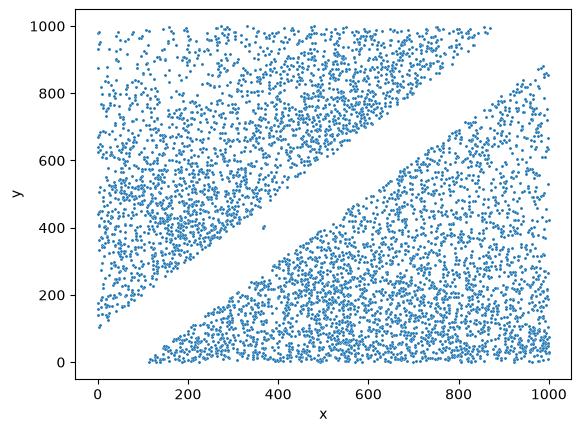

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=loc_df, x='x', y='y', s=5)

plt.xlabel('x')
plt.ylabel('y')
plt.show()

<h2>5. Evaluation</h2>

 - Arvioidaan mallin todellinen onnistuminen.
 - Selvitetään, kuinka hyvin malli vastaa sille alun perin asetettuihin liiketoimintavaatimuksiin (business requirements).<br>
 - Ei katsota mallin suorituskykyä (tämä tehdään kappaleessa 4), vaan palataan takaisin kappaleeseen 1. ja millä tavalla saavutetut tulokset vertautuu alkuperäisiin tavoitteisiin.

<h2>6. Deployment</h2>

- Malli viedään käytäntöön (deployment).
- Tähän sisältyy tulosten viestiminen ja suositusten luominen siitä, miten mallia tulisi hyödyntää käytännössä tai mitä jatkotoimenpiteitä tulisi tehdä.